In [13]:
"""
Importing sunpy and other packages
"""

from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst


from astropy import units as u
from astropy.time import Time


import matplotlib.pyplot as plt
import numpy as np 

import cdflib.xarray
import xarray as xr
import os
import urllib.request

# uncomment line below to see what datasets are available to query from the CDAWeb
# a.cdaweb.Dataset.wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

In [14]:
directory = "."
files_WIND = []
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".cdf"): 
        # print(os.path.join(directory, filename))
        # FileAsCDF = cdflib.xarray.cdf_to_xarray(filename, to_datetime=True, to_unixtime=False, fillval_to_nan=False)
        # FileAsDF = FileAsCDF.to_dataframe
        files_WIND.append(filename)


        continue
    else:
        continue

def myFunc(e):
  return e.split("_")[3]
#   return e[10:18]

# for a in range(len(files_WIND)):
#     print(files_WIND[a][10:18])
print(myFunc(files_WIND[0]))

# print(files_WIND.sort(key=myFunc))
files_WINDSorted = sorted(files_WIND, key=myFunc)
print(files_WINDSorted)

WIND = TimeSeries(files_WINDSorted, concatenate=True)
# print(WIND)


2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variabl

19951224
['wi_k0_swe_19951201_v02.cdf', 'wi_k0_swe_19951202_v02.cdf', 'wi_k0_swe_19951203_v02.cdf', 'wi_k0_swe_19951204_v02.cdf', 'wi_k0_swe_19951205_v02.cdf', 'wi_k0_swe_19951206_v02.cdf', 'wi_k0_swe_19951207_v02.cdf', 'wi_k0_swe_19951208_v02.cdf', 'wi_k0_swe_19951209_v02.cdf', 'wi_k0_swe_19951210_v02.cdf', 'wi_k0_swe_19951211_v02.cdf', 'wi_k0_swe_19951212_v02.cdf', 'wi_k0_swe_19951213_v02.cdf', 'wi_k0_swe_19951214_v02.cdf', 'wi_k0_swe_19951215_v02.cdf', 'wi_k0_swe_19951216_v02.cdf', 'wi_k0_swe_19951217_v02.cdf', 'wi_k0_swe_19951218_v02.cdf', 'wi_k0_swe_19951219_v02.cdf', 'wi_k0_swe_19951220_v02.cdf', 'wi_k0_swe_19951221_v02.cdf', 'wi_k0_swe_19951222_v02.cdf', 'wi_k0_swe_19951223_v02.cdf', 'wi_k0_swe_19951224_v02.cdf', 'wi_k0_swe_19951225_v02.cdf', 'wi_k0_swe_19951226_v02.cdf', 'wi_k0_swe_19951227_v02.cdf', 'wi_k0_swe_19951228_v02.cdf', 'wi_k0_swe_19951229_v02.cdf', 'wi_k0_swe_19951230_v02.cdf', 'wi_k0_swe_19951231_v02.cdf']


2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "V_GSE_p". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variable "Time_PB5". Assigning dimensionless units.
2026-07-29 10:56:58 - sunpy - WARNING: SunpyUserWarning: No units provided for variabl

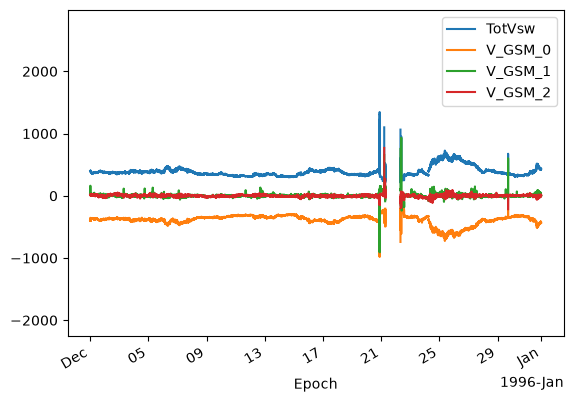

In [15]:
WIND.columns

TotVsw = np.sqrt(WIND._data["V_GSM_0"]**2 + 
                               WIND._data["V_GSM_1"]**2 + 
                               WIND._data["V_GSM_2"]**2)
WIND = WIND.add_column("TotVsw", TotVsw)

fig, ax = plt.subplots()
WIND.plot(columns=["TotVsw", "V_GSM_0", "V_GSM_1", "V_GSM_2"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)

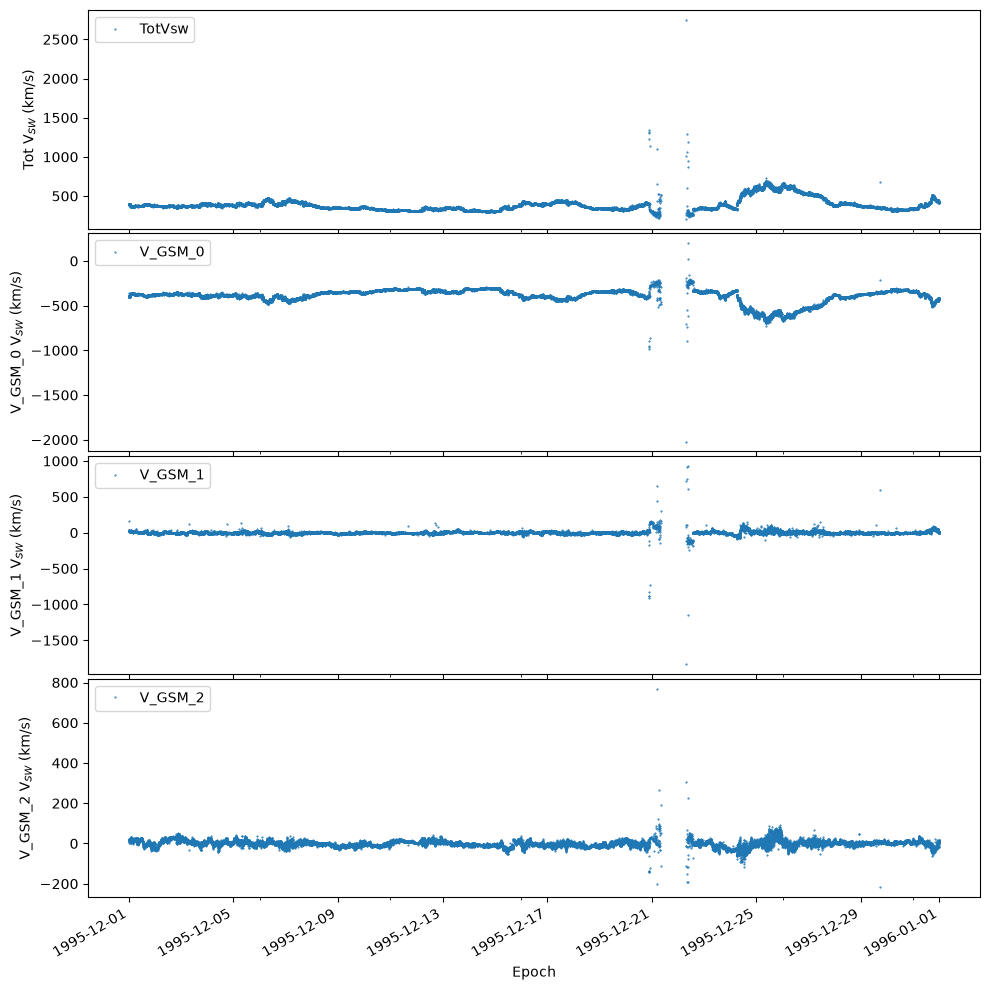

In [16]:
fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))



# total wind speed
WIND._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
# plt.axhline(400, ls="dashed")

# components of wind speed
WIND._data["V_GSM_0"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
ax[1].set_ylabel("V_GSM_0 V$_{SW}$ (km/s)")

# components of wind speed
WIND._data["V_GSM_1"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
ax[2].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")

# components of wind speed
WIND._data["V_GSM_2"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar wind is mostly radial/along the Parker spiral
ax[3].set_ylabel("V_GSM_2 V$_{SW}$ (km/s)")



for aa in ax:
    aa.legend(loc="upper left")
    # aa.axvline("2022-01-29 00:00", color='k')
    # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
    # aa.set_ylim(-400,400)

# ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
# ax[4].set_xlabel("Time")
plt.tight_layout()
plt.subplots_adjust(hspace=0.02)

In [39]:
import scipy
from scipy import stats
data = WIND.quantity("TotVsw")
# print(WIND._data["TotVsw"])
print(data)

data.cdf(0.5)
# scipy.stats.Normal.cdf(data)

[      nan 401.3611  401.39044 ... 421.18552 425.7227  430.9655 ]


AttributeError: 'Quantity' object has no 'cdf' member

[      nan 401.3611  401.39044 ... 421.18552 425.7227  430.9655 ]


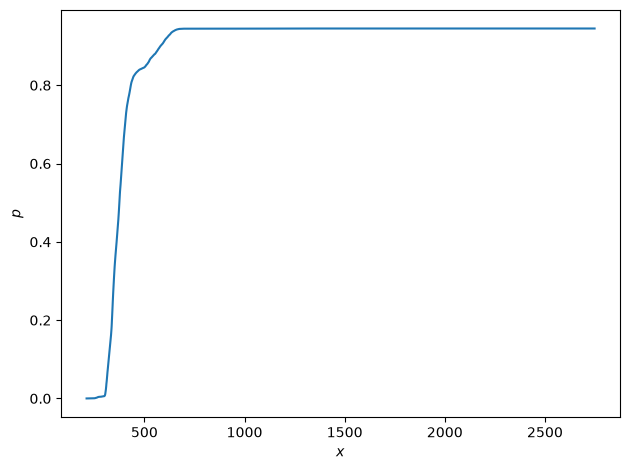

In [17]:
# import matplotlib.pyplot as plt
# import numpy as np

# create some randomly ddistributed data:
data = WIND.quantity("TotVsw")
# print(WIND._data["TotVsw"])
print(data)


# sort the data:
data_sorted = np.sort(data)
# print(data_sorted)

# calculate the proportional values of samples
p = 1. * np.arange(len(data)) / (len(data) - 1)

# plot the sorted data:
# fig = plt.figure()
# ax1 = fig.add_subplot(121)
# ax1.plot(p, data_sorted)
# ax1.set_xlabel('$p$')
# ax1.set_ylabel('$x$')

# ax2 = fig.add_subplot(122)
# ax2.plot(data_sorted, p)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$p$')
# plt.tight_layout()

# fig = plt.figure(figsize = [20, 8])

plt.plot(data_sorted, p)
plt.xlabel('$x$')
plt.ylabel('$p$')
plt.tight_layout()

In [ ]:

# p_range: Tuple[float, float] = (0.0001, 0.9999)
# probabilities = np.linspace(*p_range, size)

# x_quant = np.quantile(data_sorted, p)


# # y_quant = np.quantile(data_sortedY, pY)

# print(x_quant)

[nan nan nan ... nan nan nan]


In [25]:
def get_quantiles(
    x: pl.Series,
    # y: pl.Series,
    size: int = 500,
    p_range: Tuple[float, float] = (0.001, 0.999),
) -> Tuple[NDArray, NDArray]:

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy())
    # y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy())

    probabilities = np.linspace(*p_range, size)

    x_quantiles = np.quantile(x_sorted, probabilities)
    # y_quantiles = np.quantile(y_sorted, probabilities)

    return x_quantiles#, y_quantiles

[ 227.2694366   262.29234024  271.3728923   299.20444979  302.60493714
  303.76900899  304.53727885  305.15222992  305.57825403  306.15469007
  306.72075601  307.13751992  307.68702733  308.10431526  308.43763756
  308.86590713  309.18866999  309.53380709  309.79969864  310.08751848
  310.42306519  310.84751892  311.21502193  311.6298943   312.04425699
  312.32648723  312.68344083  313.01906192  313.34270597  313.62038422
  313.8743382   314.29592463  314.57994181  314.88412038  315.21184584
  315.4885355   315.87644666  316.32367563  316.59972392  316.86421661
  317.12685082  317.43335519  317.7257333   318.08476084  318.42075965
  318.81757543  319.16526367  319.49592419  319.86213599  320.21090899
  320.56426686  320.94111072  321.34907018  321.77482439  322.10459447
  322.41256759  322.75464958  323.07422407  323.50151903  323.89335327
  324.32757643  324.69064561  325.08556184  325.46650093  325.83031439
  326.28663906  326.60793496  326.96477068  327.35743985  327.74707817
  328.

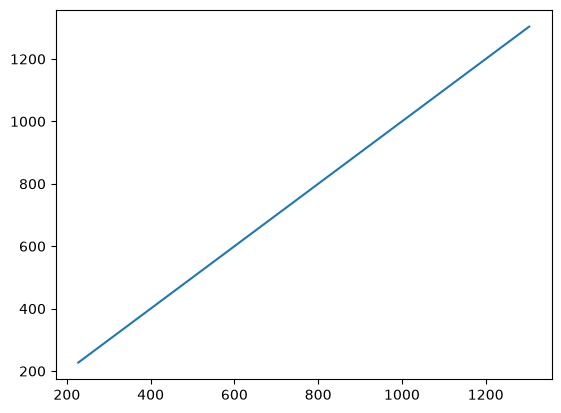

In [33]:
import polars as pl

data_sortedPLSeries = pl.Series(data_sorted)

xQuant = get_quantiles(data_sortedPLSeries, size = 500, p_range=(0.0001, 0.9999))
yQuant = get_quantiles(data_sortedPLSeries, size = 500, p_range=(0.0001, 0.9999))

print(xQuant)

plt.plot(xQuant, yQuant)

# Archived code

In [19]:
# import cdflib
# cdf_file = cdflib.CDF('wi_k0_swe_19951201_v02.cdf')
# cdf_file.cdf_info()
# print(cdf_file.varget)

# import pandas as pd
# cdf_fileDF = pd.DataFrame(cdf_file)
# print(cdf_fileDF)

# import warnings
# warnings.filterwarnings("ignore")
# WIND = TimeSeries(cdf_fileDF)


In [20]:
# import cdflib

# # CDFmerge
# # One file
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file.cdf_info()

# # #  For multiple files
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file2 = cdflib.CDF("wi_k0_swe_19951202_v02.cdf")

# directory = "."

# for file in os.listdir(directory):
#     filename = os.fsdecode(file)
#     if filename.endswith(".cdf") or filename.endswith(".py"): 
#         print(os.path.join(directory, filename))
#         FileAsCDF = cdflib.xarray.cdf_to_xarray(filename, to_datetime=True, to_unixtime=False, fillval_to_nan=False)
#         FileAsDF = FileAsCDF.to_dataframe


#         continue
#     else:
#         continue


# # X1 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951201_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)
# # X2 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951202_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)

# # # import xr.DataArray

# # giveMe = X1.to_dataframe

# # print(giveMe)


In [21]:

# # print(cdf_file.cdf_info)
# VswComponents = cdf_file.varget("V_GSM")#, startrec=0, endrec=150)
# print(VswComponents[1][2])

# TotVsw = []
# for a in range(len(VswComponents)):
#     # Calculated = )
#     # print(Calculated)
#     TotVsw.append( np.sqrt(VswComponents[a][0]**2 + VswComponents[a][1]**2 + VswComponents[a][2]**2) )

# print(len(TotVsw))
# # print(TotVsw)

# Time = cdf_file.varget("Epoch")#, startrec=0, endrec=150)
# # print(Time[1])

# DateTime = []
# for b in range(len(Time)):
#     DateTime.append (((Time[b]/1000)/3600))# /1000 milliseconds to seconds, /3600 to hours, /24 to days
# print(len(DateTime))
# # print(DateTime[0])


In [22]:
# fig, ax = plt.subplots()
# plt.plot(DateTime, TotVsw)
# # plt.legend(loc="upper right")
# # plt.ylim(-450,900)

In [23]:
# # import matplotlib.pyplot as plt
# # import numpy as np

# # create some randomly ddistributed data:
# data = TotVsw

# # sort the data:
# data_sorted = np.sort(data)

# # calculate the proportional values of samples
# p = 1. * np.arange(len(data)) / (len(data) - 1)

# # plot the sorted data:
# fig = plt.figure()
# ax1 = fig.add_subplot(121)
# ax1.plot(p, data_sorted)
# ax1.set_xlabel('$p$')
# ax1.set_ylabel('$x$')

# ax2 = fig.add_subplot(122)
# ax2.plot(data_sorted, p)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$p$')
# plt.tight_layout()

In [24]:
# fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))



# # total wind speed
# WIND._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
# ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
# # plt.axhline(400, ls="dashed")

# # components of wind speed
# WIND._data["V_GSM_0"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
# ax[1].set_ylabel("V_GSM_0 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_1"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
# ax[2].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_2"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar wind is mostly radial/along the Parker spiral
# ax[3].set_ylabel("V_GSM_2 V$_{SW}$ (km/s)")



# for aa in ax:
#     aa.legend(loc="upper left")
#     # aa.axvline("2022-01-29 00:00", color='k')
#     # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
#     # aa.set_ylim(-400,400)

# # ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
# # ax[4].set_xlabel("Time")
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.02)